# Training a Diffusion Model From Scratch

## Setup environment

In [104]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

In [105]:
# Import essential modules. Feel free to add whatever you need.
import torch
import tqdm
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import MNIST
from torchvision.transforms.v2 import ToTensor
import torchvision.transforms.v2 as transforms
import torchvision
import einops
import numpy as np
import mediapy as media

from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

device = 'cuda'


# Part 1: Training a Single-step Denoising UNet


## Implementing Simple and Composed Ops

In [106]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        return x


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        return x


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        return x

class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.AvgPool2d(7),
            nn.GELU(),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        return x

class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, 7, 7, 0),
            nn.BatchNorm2d(in_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        return x

class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.conv2(x)
        return x

class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.down = DownConv(in_channels, out_channels)
        self.conv = ConvBlock(out_channels, out_channels)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.down(x)
        x = self.conv(x)
        return x

class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up = UpConv(in_channels, out_channels)
        self.conv = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        x = self.conv(x)
        return x

## Implementing Unconditional UNet

In [107]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_hiddens = num_hiddens

        self.convblock1 = ConvBlock(in_channels, num_hiddens)
        self.downblock1 = DownBlock(num_hiddens, num_hiddens)
        self.downblock2 = DownBlock(num_hiddens, 2 * num_hiddens)
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * num_hiddens)

        self.upblock1 = UpBlock(4 * num_hiddens, num_hiddens)
        self.upblock2 = UpBlock(2 * num_hiddens, num_hiddens)
        self.convblock2 = ConvBlock(2 * num_hiddens, num_hiddens)
        # self.conv = Conv(num_hiddens, in_channels)
        self.conv = nn.Conv2d(num_hiddens, in_channels, 3, 1, 1)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        x1 = self.convblock1(x)
        x2 = self.downblock1(x1)
        x3 = self.downblock2(x2)
        x4 = self.flatten(x3)
        x5 = self.unflatten(x4)
        x6 = torch.cat([x5, x3], dim=1)
        x7 = self.upblock1(x6)
        x8 = torch.cat([x7, x2], dim=1)
        x9 = self.upblock2(x8)
        x10 = torch.cat([x9, x1], dim=1)
        x11 = self.convblock2(x10)
        x12 = self.conv(x11)
        return x12


In [108]:
net = UnconditionalUNet(1,128).to(device)
dummy_input = torch.randn(2, 1, 28, 28)

# Pass the dummy input through the model
output = net(dummy_input.to(device))
print(output.shape)

torch.Size([2, 1, 28, 28])


In [109]:
# # Adjust Dataset
# class CustomMNIST(Dataset):
#     def __init__(self, root, train=True, transform=None, download=False):
#         self.mnist = MNIST(root=root, train=train, download=download)
#         self.transform = transform

#     def __len__(self):
#         return len(self.mnist)

#     def __getitem__(self, idx):
#         # Get the original image and label
#         original_image, label = self.mnist[idx]

#         transformed_image = self.transform(original_image)

#         return original_image, label

In [110]:
class CustomMNIST(Dataset):
    def __init__(self, train=True, transform=None):
        self.mnist = MNIST(root='../data', train=train, download=True)
        self.transform = transform

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        image, _ = self.mnist[idx]

        # Apply transformations if any
        original_image = transforms.ToTensor()(image)
        transformed_image = self.transform(original_image)

        # Custom modification: Invert the image colors

        return transformed_image, original_image


## 1.2 Using the UNet to Train a Denoiser


/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


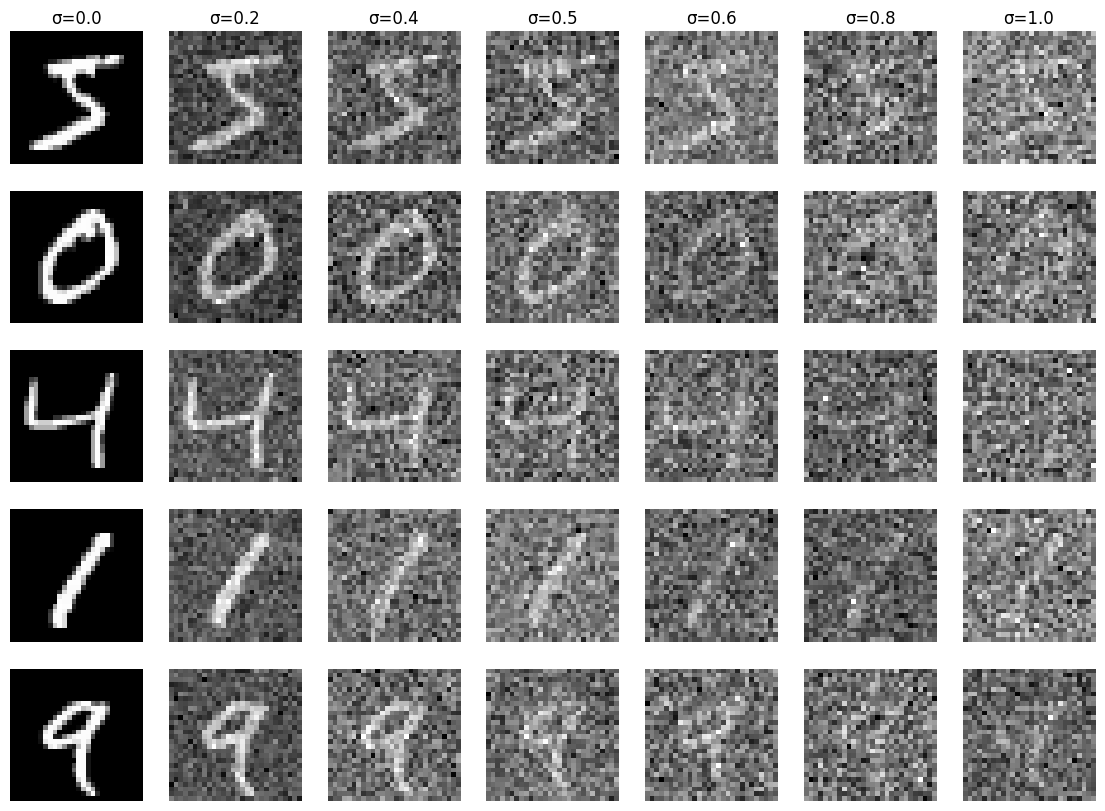

In [111]:
import matplotlib.pyplot as plt
rows, cols = 5, 7
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))

for i, sigma in enumerate([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]):
    axes[0, i].set_title('σ=' + str(sigma))
    mytransforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + torch.randn_like(x) * sigma),
    ])
    train_dataset = CustomMNIST(train=True, transform=mytransforms)
    train_loader = DataLoader(train_dataset, batch_size=rows, shuffle=False)
    images, labels = next(iter(train_loader))
    for j, image in enumerate(images):
        image = (image - image.min()) / (image.max() - image.min())
        image = einops.rearrange(image, "c h w -> h w c")
        axes[j, i].imshow(image, cmap='gray')
        axes[j, i].axis('off')

plt.show()

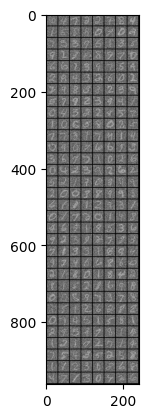

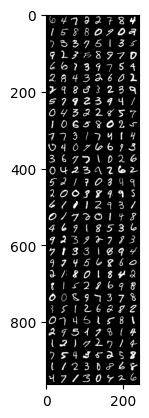

In [112]:
# Correctly set train and test dataset
sigma=0.5
mytransforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + torch.randn_like(x) * sigma),
])


train_dataset = CustomMNIST(train=True, transform=mytransforms)
test_dataset = CustomMNIST(train=False, transform=mytransforms)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

def show_image_grid(images):
  image_grid = torchvision.utils.make_grid(images)
  image_grid = einops.rearrange(image_grid, "c h w -> h w c")
  plt.imshow(image_grid.numpy())
  plt.show()

# Samples the first batch of data.
images, labels = next(iter(train_loader))
images = (images - images.min()) / (images.max() - images.min())
show_image_grid(images)

labels = (labels - labels.min()) / (labels.max() - labels.min())
show_image_grid(labels)


In [113]:
criterion = nn.MSELoss()
# TODO We need to use 1e-4 as the learning rate but im poor so i left it at 12-3 for now
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
num_epochs = 1
for epoch in range(num_epochs):
    running_loss = 0

    # Wrap in a progress bar to display progress during training.
    progress_bar = tqdm.tqdm(train_loader)

    for i, data in enumerate(progress_bar):
        inputs, labels = data

        # We need to put our data on the GPU too.
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 19:    # print every 20 minibatches
            writer.add_scalar("Loss/train in steps", running_loss / 20, i + 1 + epoch * len(train_loader))
            writer.add_scalar("Loss/train", running_loss / 20, epoch)
            running_loss = 0.0

writer.flush()
print('Finished Training')

100%|██████████| 235/235 [01:59<00:00,  1.97it/s]

Finished Training


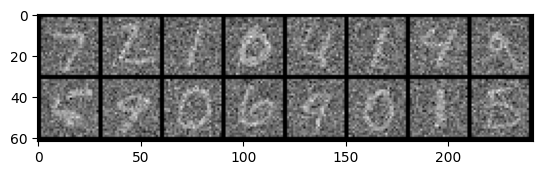

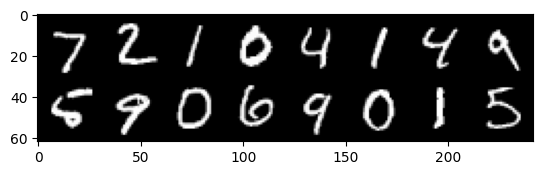

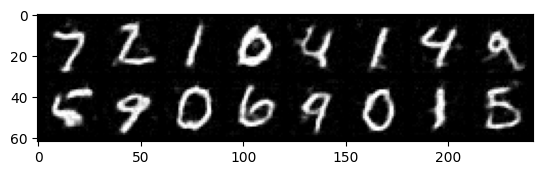

In [114]:
sigma=0.5
mytransforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + torch.randn_like(x) * sigma),
])

test_dataset = CustomMNIST(train=False, transform=mytransforms)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

images, labels = next(iter(test_loader))
images = images[:16]
labels = labels[:16]

images.to(device)
labels.to(device)

images = (images - images.min()) / (images.max() - images.min())

show_image_grid(images)
show_image_grid(labels)

outputs = net(images.to(device))
show_image_grid(outputs.to('cpu'))

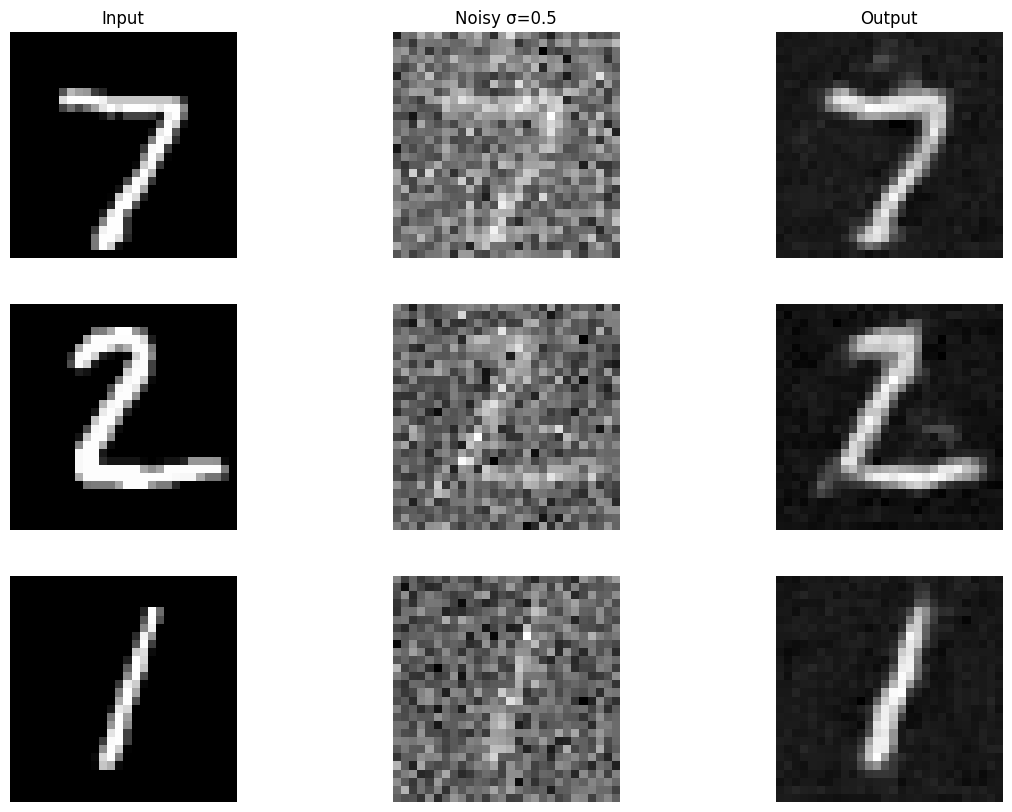

In [115]:
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes[0, 0].set_title('Input')
axes[0, 1].set_title('Noisy σ=0.5')
axes[0, 2].set_title('Output')

for i, imagecollection in enumerate([labels[:3], images[:3], outputs[:3].to('cpu').detach()]):
    for j, image in enumerate(imagecollection):
        image = (image - image.min()) / (image.max() - image.min())
        image = einops.rearrange(image, "c h w -> h w c")
        axes[j, i].imshow(image, cmap='gray')
        axes[j, i].axis('off')

plt.show()

In [116]:
# Now we train for the left over 4 epochs for a total of 5
num_epochs = 4
for epoch in range(1, num_epochs):
    running_loss = 0

    # Wrap in a progress bar to display progress during training.
    progress_bar = tqdm.tqdm(train_loader)

    for i, data in enumerate(progress_bar):
        inputs, labels = data

        # We need to put our data on the GPU too.
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 19:    # print every 20 minibatches
            writer.add_scalar("Loss/train in steps", running_loss / 20, i + 1 + epoch * len(train_loader))
            writer.add_scalar("Loss/train", running_loss / 20, epoch)
            running_loss = 0.0

writer.flush()
print('Finished Training')

100%|██████████| 235/235 [01:50<00:00,  2.13it/s]

Finished Training


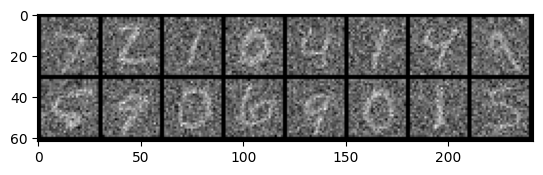

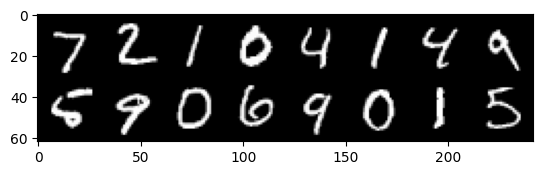

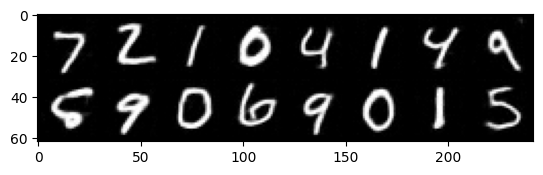

In [117]:
images, labels = next(iter(test_loader))
images = images[:16]
labels = labels[:16]

images.to(device)
labels.to(device)

images = (images - images.min()) / (images.max() - images.min())

show_image_grid(images)
show_image_grid(labels)

outputs = net(images.to(device))
show_image_grid(outputs.to('cpu'))

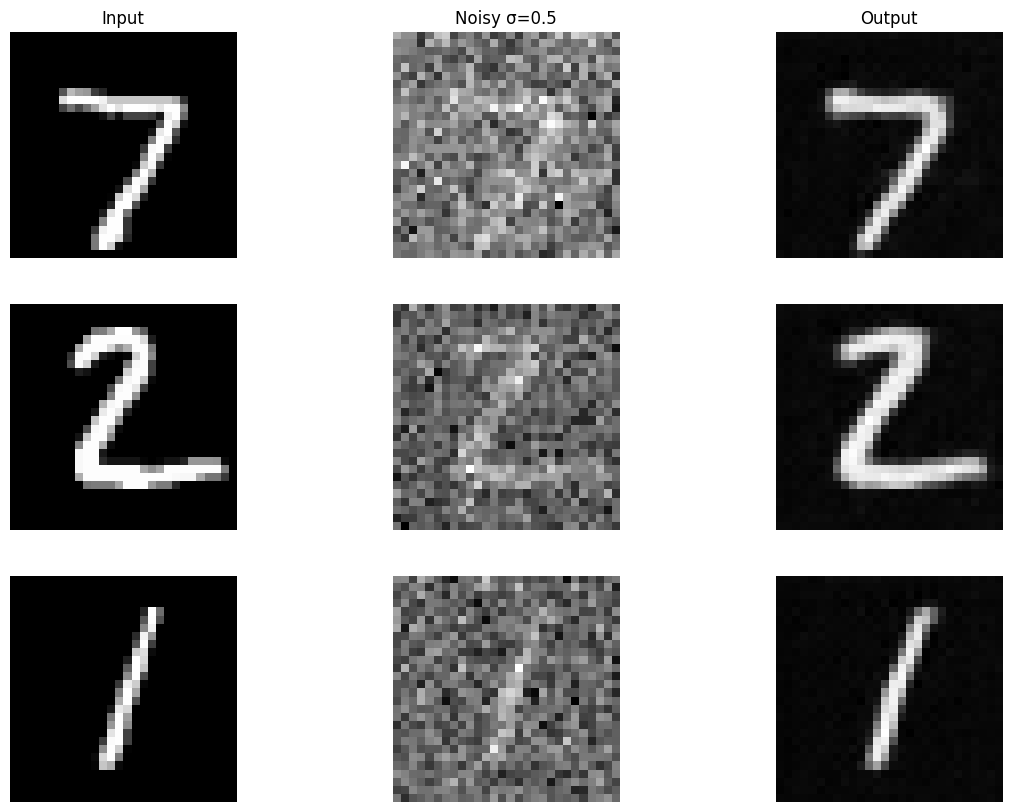

In [118]:
# Now we put display this result too
outputs = net(images.to(device))
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes[0, 0].set_title('Input')
axes[0, 1].set_title('Noisy σ=0.5')
axes[0, 2].set_title('Output')

for i, imagecollection in enumerate([labels[:3], images[:3], outputs[:3].to('cpu').detach()]):
    for j, image in enumerate(imagecollection):
        image = (image - image.min()) / (image.max() - image.min())
        image = einops.rearrange(image, "c h w -> h w c")
        axes[j, i].imshow(image, cmap='gray')
        axes[j, i].axis('off')

plt.show()


## 1.2.2 Out of distribution testing

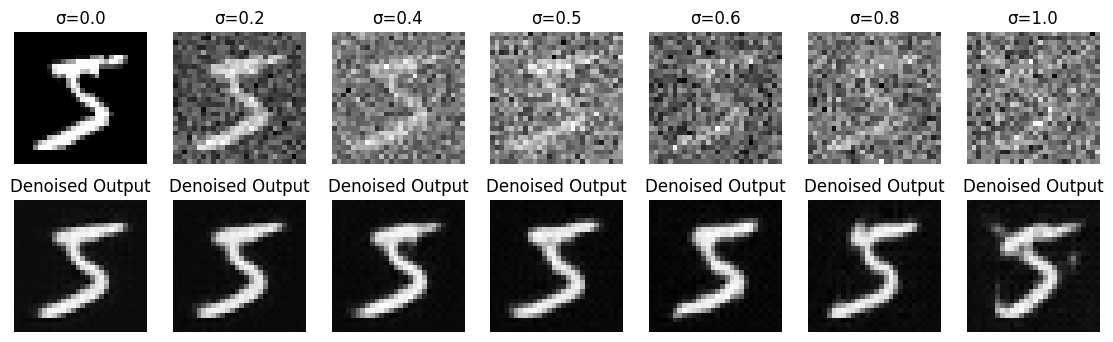

In [119]:
rows, cols = 2, 7
fig, axes = plt.subplots(rows, cols, figsize=(14, 4))

for i, sigma in enumerate([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]):
    axes[0, i].set_title('σ=' + str(sigma))
    axes[1, i].set_title('Denoised Output')
    mytransforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + torch.randn_like(x) * sigma),
    ])
    sigma_test_dataset = CustomMNIST(train=True, transform=mytransforms)
    sigma_test_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
    images, _ = next(iter(sigma_test_loader))
    for j, image in enumerate(images):
        outputs = net(images.to(device))
        image = (image - image.min()) / (image.max() - image.min())
        image = einops.rearrange(image, "c h w -> h w c")
        axes[0, i].imshow(image, cmap='gray')
        axes[0, i].axis('off')
        outputs = einops.rearrange(outputs[0], "c h w -> h w c")
        axes[1, i].imshow(outputs.to('cpu').detach(), cmap='gray')
        axes[1, i].axis('off')
plt.show()

# Part 2: Training a Diffusion Model

## Implementing a Time-conditioned UNet

In [122]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        return x

class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.num_hiddens = num_hiddens

        self.convblock1 = ConvBlock(in_channels, num_hiddens)
        self.downblock1 = DownBlock(num_hiddens, num_hiddens)
        self.downblock2 = DownBlock(num_hiddens, 2 * num_hiddens)
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * num_hiddens)

        self.upblock1 = UpBlock(4 * num_hiddens, num_hiddens)
        self.upblock2 = UpBlock(2 * num_hiddens, num_hiddens)
        self.convblock2 = ConvBlock(2 * num_hiddens, num_hiddens)
        self.conv = nn.Conv2d(num_hiddens, in_channels, 3, 1, 1)

        # New stuff is here
        self.fcblock1 = FCBlock(1, 2 * num_hiddens)
        self.fcblock2 = FCBlock(1, num_hiddens)

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        t1 = self.fcblock1(t)
        t2 = self.fcblock2(t)
        t1 = t1.view(-1, 2 * self.num_hiddens, 1, 1)
        t2 = t2.view(-1, self.num_hiddens, 1, 1)

        x1 = self.convblock1(x)
        x2 = self.downblock1(x1)
        x3 = self.downblock2(x2)
        x4 = self.flatten(x3)
        x5 = self.unflatten(x4)
        x5  = x5 + t1
        x6 = torch.cat([x5, x3], dim=1)
        x7 = self.upblock1(x6)
        x7 = x7 + t2

        x8 = torch.cat([x7, x2], dim=1)
        x9 = self.upblock2(x8)
        x10 = torch.cat([x9, x1], dim=1)
        x11 = self.convblock2(x10)
        x12 = self.conv(x11)
        return x12


## Implementing DDPM Forward and Inverse Process for Time-conditioned Denoising

In [123]:
def show_image_grid(images):
  image_grid = torchvision.utils.make_grid(images)
  image_grid = einops.rearrange(image_grid, "c h w -> h w c")
  plt.imshow(image_grid.numpy())
  plt.show()

In [124]:
def ddpm_schedule(beta1: float, beta2: float, num_ts: int) -> dict:
    """Constants for DDPM training and sampling.

    Arguments:
        beta1: float, starting beta value.
        beta2: float, ending beta value.
        num_ts: int, number of timesteps.

    Returns:
        dict with keys:
            betas: linear schedule of betas from beta1 to beta2.
            alphas: 1 - betas.
            alpha_bars: cumulative product of alphas.
    """
    betas = np.linspace(beta1, beta2, num_ts)
    alphas = 1 - betas
    dictionary = {
        "betas": betas.tolist(),
        "alphas": alphas.tolist(),
        "alpha_bars": (1 - betas).cumprod()
    }
    assert beta1 < beta2 < 1.0, "Expect beta1 < beta2 < 1.0."
    return dictionary

# ddpm_schedulee = ddpm_schedule(0.0001, 0.02, 5)
# print(ddpm_schedulee['alphas'])
# print(ddpm_schedulee['alpha_bars'])


In [125]:
def ddpm_forward(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) diffusion loss.
    """
    unet.train()
    # YOUR CODE HERE.
    alpha_bars = torch.tensor(ddpm_schedule["alpha_bars"], dtype=torch.float32, device=device)

    t = torch.randint(1, num_ts, (x_0.size(0),), device=device)
    new = (alpha_bars[t]** 0.5).view(-1, 1, 1, 1) * x_0
    eps = torch.randn_like(x_0).to(device)
    x_t = (alpha_bars[t]** 0.5).view(-1, 1, 1, 1) * x_0 + ((1 - alpha_bars[t]) ** 0.5).view(-1, 1, 1, 1) * eps
    t_normalized = t / float(num_ts)
    t_normalized = t_normalized.view(-1, 1, 1, 1)
    predicted_eps = unet(x_t, t_normalized)
    loss = torch.nn.functional.mse_loss(predicted_eps, eps)
    # print(loss.item())
    return loss

# images, labels = next(iter(train_loader))

# unet = TimeConditionalUNet(1, 1, 128).to(device)
# ddpm_schedulee = ddpm_schedule(0.0001, 0.02, 300)

# test = ddpm_forward(
#             unet, ddpm_schedulee, images.to(device), 300
#         )


In [127]:
@torch.inference_mode()
def ddpm_sample(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # YOUR CODE HERE.
    # torch.manual_seed(1234)
    alpha_bars = torch.tensor(ddpm_schedule["alpha_bars"], dtype=torch.float32, device=device)
    betas = torch.tensor(ddpm_schedule["betas"], dtype=torch.float32, device=device)
    alphas = torch.tensor(ddpm_schedule["alphas"], dtype=torch.float32, device=device)

    sampleamount = 40
    x_T = torch.randn(sampleamount, 1, img_wh[0], img_wh[1]).to(device)


    with torch.no_grad():
        for t in range(299, 0, -1):
            alpha_cumprod = alpha_bars[t]
            alpha_cumprod_prev = alpha_bars[t - 1]
            if t > 1:
                z = torch.randn(sampleamount, 1, img_wh[0], img_wh[1]).to(torch.device(device))
            else:
                z = 0

            t_normalized = t / float(num_ts)
            t_normalized = torch.tensor(t_normalized, dtype=torch.float32, device=device)
            t_normalized = t_normalized.repeat(sampleamount, 1, 1, 1)
            noise_est = unet(x_T, t_normalized)
            clean_est = (x_T - (1 - alpha_cumprod)**0.5 * noise_est) / (alpha_cumprod**0.5)
            pred_prev_image = (alpha_cumprod_prev**0.5 * betas[t] * clean_est)/(1 - alpha_cumprod) + (alphas[t] ** 0.5 * (1 - alpha_cumprod_prev) * x_T)/(1 - alpha_cumprod) + z * (betas[t] ** 0.5)
            x_T = pred_prev_image
            # media.show_image(np.transpose(x_T[0].cpu().detach().numpy(), (1, 2, 0)) / 2. + 0.5)

        x_T = x_T.cpu().detach().numpy()
    return x_T

# # Define image dimensions
# img_wh = (28, 28)  # For a 64x64 image

# images, labels = next(iter(train_loader))

# # unet = TimeConditionalUNet(1, 1, 128).to(device)
# ddpm_schedulee = ddpm_schedule(0.0001, 0.02, 300)
# # Sampling
# sampled_image = ddpm_sample(
#     unet=unet,
#     ddpm_schedule=ddpm_schedulee,
#     img_wh=img_wh,
#     num_ts=300,
#     seed=42,
# )
# media.set_show_save_dir('output2')
# media.show_image(np.transpose(sampled_image[0], (1, 2, 0)) / 2. + 0.5)


In [128]:
# Load the data
train_dataset = MNIST('../data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = MNIST('../data', train=False, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
print(train_loader)

In [129]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = ddpm_schedule(betas[0], betas[1], num_ts)

        # for k, v in ddpm_schedule(betas[0], betas[1], num_ts).items():
        #     self.register_buffer(k, v, persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, img_wh, self.num_ts, seed
        )

In [130]:
# Initialize UNet, DDPM, and dataloader
unet = TimeConditionalUNet(1, 1, 64).to(device)
model = DDPM(unet=unet).to(device)

epoch  1


100%|██████████| 469/469 [00:48<00:00,  9.68it/s]


epoch  2


100%|██████████| 469/469 [00:47<00:00,  9.86it/s]


epoch  3


100%|██████████| 469/469 [00:47<00:00,  9.97it/s]


epoch  4


100%|██████████| 469/469 [00:46<00:00,  9.99it/s]


epoch  5


100%|██████████| 469/469 [00:47<00:00,  9.94it/s]


epoch  6


100%|██████████| 469/469 [00:46<00:00, 10.07it/s]


epoch  7


100%|██████████| 469/469 [00:46<00:00,  9.99it/s]


epoch  8


100%|██████████| 469/469 [00:47<00:00,  9.95it/s]


epoch  9


100%|██████████| 469/469 [00:47<00:00,  9.94it/s]


epoch  10


100%|██████████| 469/469 [00:46<00:00, 10.02it/s]


epoch  11


100%|██████████| 469/469 [00:46<00:00, 10.00it/s]


epoch  12


100%|██████████| 469/469 [00:47<00:00,  9.92it/s]


epoch  13


100%|██████████| 469/469 [00:46<00:00, 10.05it/s]


epoch  14


100%|██████████| 469/469 [00:47<00:00,  9.95it/s]


epoch  15


100%|██████████| 469/469 [00:47<00:00,  9.96it/s]


epoch  16


100%|██████████| 469/469 [00:46<00:00, 10.05it/s]


epoch  17


100%|██████████| 469/469 [00:46<00:00, 10.01it/s]


epoch  18


100%|██████████| 469/469 [00:46<00:00, 10.00it/s]


epoch  19


100%|██████████| 469/469 [00:47<00:00,  9.94it/s]


epoch  20


100%|██████████| 469/469 [00:46<00:00, 10.03it/s]


Finished Training


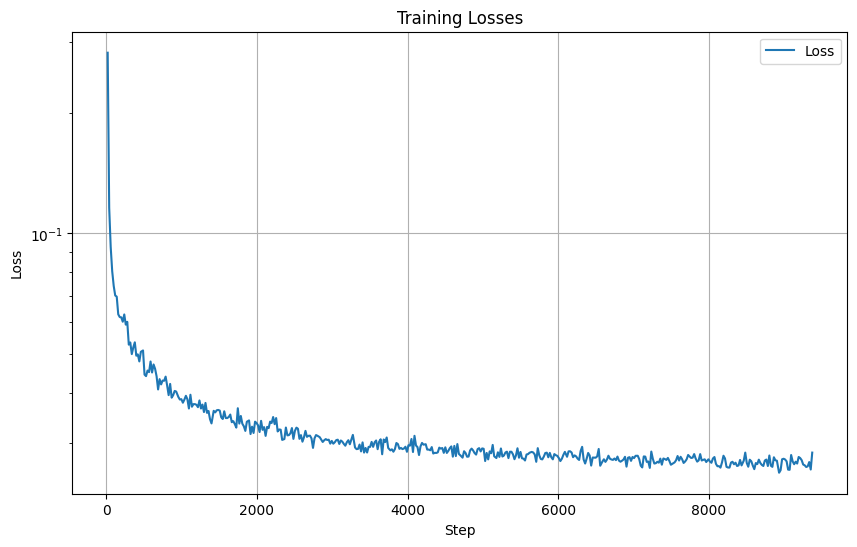

In [131]:
# Hyperparameters
num_epochs = 20
batch_size = 128
learning_rate = 1e-3
losses = []
steps = []

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1**(1.0/num_epochs))
for epoch in range(num_epochs):
    print("epoch ", epoch + 1)
    model.train()
    running_loss = 0

    # Wrap in a progress bar to display progress during training.
    progress_bar = tqdm.tqdm(train_loader)

    for i, data in enumerate(progress_bar):
        inputs, _ = data
        inputs = inputs.to(device)
        optimizer.zero_grad()
        loss = model(inputs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 19:    # print every 20 minibatches
            losses.append(running_loss / 20)
            steps.append(i + 1 + epoch * len(train_loader))

            writer.add_scalar("Loss/train in steps", running_loss / 20, i + 1 + epoch * len(train_loader))
            writer.add_scalar("Loss/train", running_loss / 20, epoch)
            running_loss = 0.0

    scheduler.step()


writer.flush()
print('Finished Training')

plt.figure(figsize=(10, 6))
plt.plot(steps, losses, label='Loss')

plt.title('Training Losses')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.show()

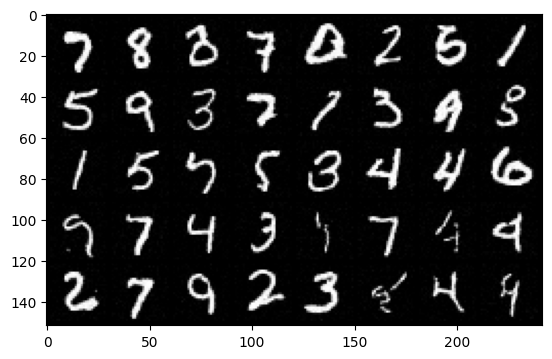

In [133]:
  generated_images = None
  with torch.inference_mode():
      generated_images = model.sample(img_wh=(28, 28))
  show_image_grid(torch.from_numpy(generated_images))

### Implementing class-conditioned UNet

In [134]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.num_hiddens = num_hiddens
        self.num_classes = num_classes

        self.convblock1 = ConvBlock(in_channels, num_hiddens)
        self.downblock1 = DownBlock(num_hiddens, num_hiddens)
        self.downblock2 = DownBlock(num_hiddens, 2 * num_hiddens)
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * num_hiddens)

        self.upblock1 = UpBlock(4 * num_hiddens, num_hiddens)
        self.upblock2 = UpBlock(2 * num_hiddens, num_hiddens)
        self.convblock2 = ConvBlock(2 * num_hiddens, num_hiddens)
        self.conv = nn.Conv2d(num_hiddens, in_channels, 3, 1, 1)

        # New stuff is here
        self.fcblock1 = FCBlock(1, 2 * num_hiddens)
        self.fcblock2 = FCBlock(1, num_hiddens)
        self.fcblock3 = FCBlock(10, 2 * num_hiddens)
        self.fcblock4 = FCBlock(10, num_hiddens)

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        t1 = self.fcblock1(t)
        t2 = self.fcblock2(t)
        c = c.view(c.size(0), -1)
        c1 = self.fcblock3(c)
        c2 = self.fcblock4(c)

        t1 = t1.view(-1, 2 * self.num_hiddens, 1, 1)
        t2 = t2.view(-1, self.num_hiddens, 1, 1)
        c1 = c1.view(-1, 2 * self.num_hiddens, 1, 1)
        c2 = c2.view(-1, self.num_hiddens, 1, 1)

        x1 = self.convblock1(x)
        x2 = self.downblock1(x1)
        x3 = self.downblock2(x2)
        x4 = self.flatten(x3)
        x5 = self.unflatten(x4)
        x5  = x5 + t1 +c1
        x6 = torch.cat([x5, x3], dim=1)
        x7 = self.upblock1(x6)
        x7 = x7 + t2 + c2

        x8 = torch.cat([x7, x2], dim=1)
        x9 = self.upblock2(x8)
        x10 = torch.cat([x9, x1], dim=1)
        x11 = self.convblock2(x10)
        x12 = self.conv(x11)
        return x12

In [135]:
def ddpm_forward(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) diffusion loss.
    """
    unet.train()
    # YOUR CODE HERE.
    alpha_bars = torch.tensor(ddpm_schedule["alpha_bars"], dtype=torch.float32, device=device)
    # I just hardcoded the 10 here
    one_hot = torch.nn.functional.one_hot(c, num_classes=10)
    if torch.rand(1).item() < p_uncond:
      one_hot = torch.zeros_like(one_hot)
    one_hot = one_hot.type(torch.float32)
    one_hot = one_hot.view(-1, 10, 1, 1)
    t = torch.randint(1, num_ts, (x_0.size(0),), device=device)


    new = (alpha_bars[t]** 0.5).view(-1, 1, 1, 1) * x_0
    eps = torch.randn_like(x_0).to(device)
    x_t = (alpha_bars[t]** 0.5).view(-1, 1, 1, 1) * x_0 + ((1 - alpha_bars[t]) ** 0.5).view(-1, 1, 1, 1) * eps
    t_normalized = t / float(num_ts)
    t_normalized = t_normalized.view(-1, 1, 1, 1)
    predicted_eps = unet(x_t, one_hot, t_normalized)
    loss = torch.nn.functional.mse_loss(predicted_eps, eps)
    return loss

images, labels = next(iter(train_loader))
unet = ClassConditionalUNet(1, 10, 64).to(device)
ddpm_schedulee = ddpm_schedule(0.0001, 0.02, 300)
test = ddpm_forward(
            unet, ddpm_schedulee, images.to(device), labels.to(device), 0.1, 300
        )


In [136]:
@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # YOUR CODE HERE.
    alpha_bars = torch.tensor(ddpm_schedule["alpha_bars"], dtype=torch.float32, device=device)
    betas = torch.tensor(ddpm_schedule["betas"], dtype=torch.float32, device=device)
    alphas = torch.tensor(ddpm_schedule["alphas"], dtype=torch.float32, device=device)

    sampleamount = 4
    x_T = torch.randn(sampleamount, 1, img_wh[0], img_wh[1]).to(device)


    with torch.no_grad():
        for t in range(299, 0, -1):
            alpha_cumprod = alpha_bars[t]
            alpha_cumprod_prev = alpha_bars[t - 1]
            if t > 1:
                z = torch.randn(sampleamount, 1, img_wh[0], img_wh[1]).to(torch.device(device))
            else:
                z = 0

            one_hot = torch.nn.functional.one_hot(c, num_classes=10)
            one_zero = torch.zeros_like(one_hot)
            one_hot = one_hot.type(torch.float32).view(-1, 10, 1, 1)
            one_zero = one_zero.type(torch.float32).view(-1, 10, 1, 1)

            t_normalized = t / float(num_ts)
            t_normalized = torch.tensor(t_normalized, dtype=torch.float32, device=device)
            t_normalized = t_normalized.repeat(sampleamount, 1, 1, 1)

            predicted_eps_hot = unet(x_T, one_hot, t_normalized)
            predicted_eps_zero = unet(x_T, one_zero, t_normalized)
            noise_est = predicted_eps_hot + guidance_scale * (predicted_eps_hot - predicted_eps_zero)
            clean_est = (x_T - (1 - alpha_cumprod)**0.5 * noise_est) / (alpha_cumprod**0.5)
            pred_prev_image = (alpha_cumprod_prev**0.5 * betas[t] * clean_est)/(1 - alpha_cumprod) + (alphas[t] ** 0.5 * (1 - alpha_cumprod_prev) * x_T)/(1 - alpha_cumprod) + z * (betas[t] ** 0.5)
            x_T = pred_prev_image
            # media.show_image(np.transpose(x_T[0].cpu().detach().numpy(), (1, 2, 0)) / 2. + 0.5)

        x_T = x_T.cpu().detach().numpy()
    return x_T

# Define image dimensions
img_wh = (28, 28)  # For a 64x64 image

images, labels = next(iter(train_loader))

# unet = TimeConditionalUNet(1, 1, 128).to(device)
ddpm_schedulee = ddpm_schedule(0.0001, 0.02, 300)
# Sampling
sampled_image = ddpm_sample(
    unet=unet,
    ddpm_schedule=ddpm_schedulee,
    c=torch.tensor(4).to(device),
    img_wh=img_wh,
    num_ts=300,
    seed=42,
)
media.set_show_save_dir('output2')
media.show_image(np.transpose(sampled_image[0], (1, 2, 0)) / 2. + 0.5)


""


In [137]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = ddpm_schedule(betas[0], betas[1], num_ts)

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, c, img_wh, self.num_ts, guidance_scale, seed
        )

In [138]:
# Initialize UNet, DDPM, and dataloader
unet = ClassConditionalUNet(1, 10, 64).to(device)
model = DDPM(unet=unet).to(device)

epoch  1


100%|██████████| 469/469 [00:47<00:00,  9.86it/s]


epoch  2


100%|██████████| 469/469 [00:47<00:00,  9.90it/s]


epoch  3


100%|██████████| 469/469 [00:47<00:00,  9.87it/s]


epoch  4


100%|██████████| 469/469 [00:47<00:00,  9.92it/s]


epoch  5


100%|██████████| 469/469 [00:47<00:00,  9.92it/s]


epoch  6


100%|██████████| 469/469 [00:47<00:00,  9.90it/s]


epoch  7


100%|██████████| 469/469 [00:47<00:00,  9.95it/s]


epoch  8


100%|██████████| 469/469 [00:47<00:00,  9.90it/s]


epoch  9


100%|██████████| 469/469 [00:47<00:00,  9.84it/s]


epoch  10


100%|██████████| 469/469 [00:47<00:00,  9.95it/s]


epoch  11


100%|██████████| 469/469 [00:47<00:00,  9.93it/s]


epoch  12


100%|██████████| 469/469 [00:47<00:00,  9.84it/s]


epoch  13


100%|██████████| 469/469 [00:47<00:00,  9.89it/s]


epoch  14


100%|██████████| 469/469 [00:47<00:00,  9.96it/s]


epoch  15


100%|██████████| 469/469 [00:47<00:00,  9.89it/s]


epoch  16


100%|██████████| 469/469 [00:47<00:00,  9.79it/s]


epoch  17


100%|██████████| 469/469 [00:47<00:00,  9.87it/s]


epoch  18


100%|██████████| 469/469 [00:47<00:00,  9.96it/s]


epoch  19


100%|██████████| 469/469 [00:47<00:00,  9.80it/s]


epoch  20


100%|██████████| 469/469 [00:47<00:00,  9.91it/s]


Finished Training


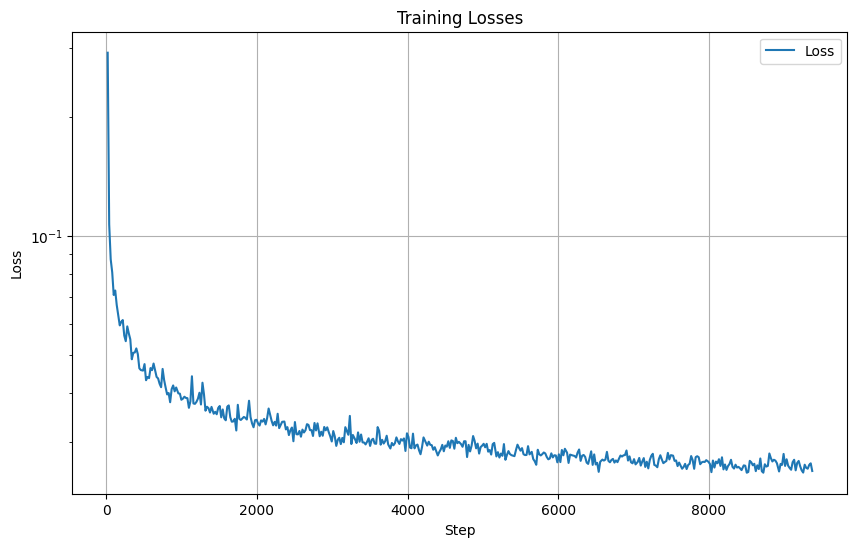

In [139]:
# Hyperparameters
num_epochs = 20
batch_size = 128
learning_rate = 1e-3
losses = []
steps = []

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1**(1.0/num_epochs))
for epoch in range(num_epochs):
    print("epoch ", epoch + 1)
    model.train()
    running_loss = 0

    # Wrap in a progress bar to display progress during training.
    progress_bar = tqdm.tqdm(train_loader)

    for i, data in enumerate(progress_bar):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        loss = model(inputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 19:    # print every 20 minibatches
            losses.append(running_loss / 20)
            steps.append(i + 1 + epoch * len(train_loader))

            writer.add_scalar("Loss/train in steps", running_loss / 20, i + 1 + epoch * len(train_loader))
            writer.add_scalar("Loss/train", running_loss / 20, epoch)
            running_loss = 0.0

    scheduler.step()


writer.flush()
print('Finished Training')

plt.figure(figsize=(10, 6))
plt.plot(steps, losses, label='Loss')

plt.title('Training Losses')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.show()

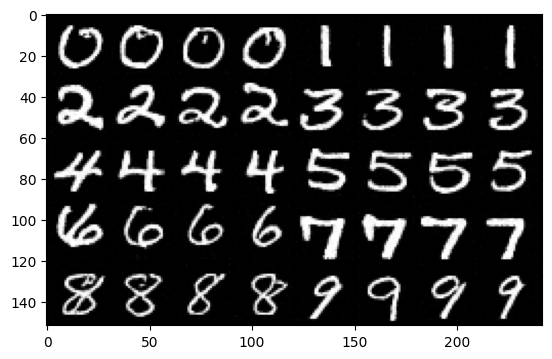

In [140]:
  generated_images = None
  with torch.inference_mode():
        generated_images = model.sample(img_wh=(28, 28), c=torch.tensor(0).to(device))
  for i in range(1, 10):
    with torch.inference_mode():
        generated_images_new = model.sample(img_wh=(28, 28), c=torch.tensor(i).to(device))
        generated_images= np.concatenate((generated_images, generated_images_new), axis=0)
  show_image_grid(torch.from_numpy(generated_images))